Enter category (or 'done' to finish):  Concert
Enter amount:  310
Enter date (YYYY-MM-DD):  2025-09-10
Enter type (Income/Expense):  Expense
Enter category (or 'done' to finish):  Salary
Enter amount:  1500
Enter date (YYYY-MM-DD):  2025-09-01
Enter type (Income/Expense):  Income
Enter category (or 'done' to finish):  Savings
Enter amount:  200
Enter date (YYYY-MM-DD):  2025-09-20
Enter type (Income/Expense):  Expense
Enter category (or 'done' to finish):  Groceries
Enter amount:  200
Enter date (YYYY-MM-DD):  2025-09-15
Enter type (Income/Expense):  Expense
Enter category (or 'done' to finish):  done


=== LATEST MONTH (2025-09) ===
Income (month):      $1,500.00
Expenses (month):    $510.00
Savings (month):     $200.00
Money Left (month):  $790.00

=== CUMULATIVE (ALL TIME) ===
Cumulative Savings:    $700.00
Cumulative Money Left: $8,290.00

Saved to finance_tracker.xlsx (Transactions + Summary + IncomeExpenseTotals).


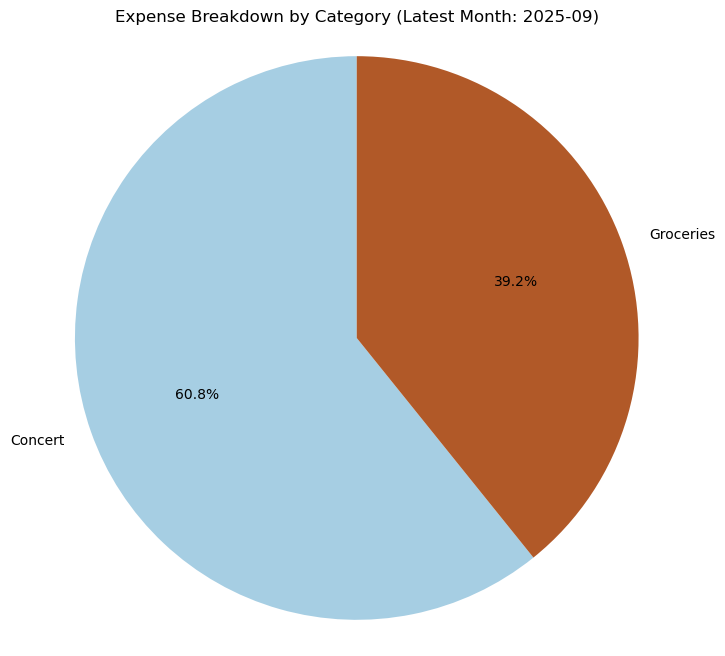

In [2]:
import os
from typing import Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class FinanceTracker:
    """
    Finance tracker that stores transactions internally with positive amounts,
    and exports expenses as negative values to Excel.
    """

    # ----------------------------
    # Configuration / Constants
    # ----------------------------
    REQUIRED_COLUMNS = ["Category", "Amount", "Date", "Type"]

    SHEET_TRANSACTIONS = "Transactions"
    SHEET_SUMMARY = "Today's Summary"          # <-- Rename this if you want a different Summary tab name
    SHEET_TOTALS = "IncomeExpenseTotals"

    def __init__(self, excel_path: str = "finance_tracker.xlsx"):
        self.excel_path = excel_path
        self.df = self._load_transactions()
        self._normalize_df()

    # ============================================================
    # Load / Normalize
    # ============================================================
    def _load_transactions(self) -> pd.DataFrame:
        """Load existing transactions from Excel, or return an empty DataFrame."""
        if not os.path.exists(self.excel_path):
            return pd.DataFrame(columns=self.REQUIRED_COLUMNS)

        try:
            tx = pd.read_excel(self.excel_path, sheet_name=self.SHEET_TRANSACTIONS)
        except Exception:
            return pd.DataFrame(columns=self.REQUIRED_COLUMNS)

        # Rebuild/standardize Date
        tx = tx.copy()
        if "Date" in tx.columns:
            tx["Date"] = pd.to_datetime(tx["Date"], errors="coerce").dt.normalize()
        elif {"Year", "Month", "Day"}.issubset(tx.columns):
            tx["Date"] = pd.to_datetime(
                dict(year=tx["Year"], month=tx["Month"], day=tx["Day"]),
                errors="coerce",
            ).dt.normalize()
        else:
            tx["Date"] = pd.NaT

        # Ensure required columns exist
        for col in ["Category", "Type", "Amount"]:
            if col not in tx.columns:
                tx[col] = None

        # Store amounts as absolute internally (Excel might have negatives for expenses)
        tx["Amount"] = pd.to_numeric(tx["Amount"], errors="coerce").fillna(0.0).abs()

        return tx[self.REQUIRED_COLUMNS].copy()

    def _normalize_df(self) -> None:
        """Force consistent dtypes/values and drop invalid rows."""
        # Ensure required columns
        for col in self.REQUIRED_COLUMNS:
            if col not in self.df.columns:
                self.df[col] = pd.Series(dtype="object")

        self.df["Category"] = self.df["Category"].astype(str).str.strip()
        self.df["Type"] = self.df["Type"].astype(str).str.strip().str.title()
        self.df["Amount"] = pd.to_numeric(self.df["Amount"], errors="coerce").fillna(0.0).abs()
        self.df["Date"] = pd.to_datetime(self.df["Date"], errors="coerce").dt.normalize()

        # Drop invalid rows
        self.df = self.df.dropna(subset=["Date"])
        self.df = self.df[self.df["Type"].isin(["Income", "Expense"])].copy()

    # ============================================================
    # Add Records / User Input
    # ============================================================
    @staticmethod
    def _parse_date(date_str: str) -> pd.Timestamp:
        dt = pd.to_datetime(date_str, errors="coerce")
        if pd.isna(dt):
            raise ValueError("Invalid date. Use YYYY-MM-DD (example: 2025-12-17).")
        return dt.normalize()

    @staticmethod
    def _parse_amount(amount) -> float:
        amt = float(amount)
        return abs(amt)

    def add_record(self, category: str, amount, date: str, record_type: str) -> None:
        """Add a transaction, preventing exact duplicates."""
        category = str(category).strip()
        record_type = str(record_type).strip().title()

        if record_type not in ["Income", "Expense"]:
            raise ValueError("Type must be Income or Expense.")

        date_parsed = self._parse_date(date)
        amount_parsed = self._parse_amount(amount)

        new_row = pd.DataFrame(
            [[category, amount_parsed, date_parsed, record_type]],
            columns=self.REQUIRED_COLUMNS,
        )

        is_dup = (
            (self.df["Category"] == category)
            & (self.df["Amount"] == amount_parsed)
            & (self.df["Date"] == date_parsed)
            & (self.df["Type"] == record_type)
        ).any()

        if not is_dup:
            self.df = pd.concat([self.df, new_row], ignore_index=True)
            self._normalize_df()

    def prompt_user_for_transactions(self) -> None:
        """CLI loop for entering new transactions."""
        while True:
            category = input("Enter category (or 'done' to finish): ").strip()
            if category.lower() == "done":
                break

            amount_str = input("Enter amount: ").strip()
            try:
                amount = float(amount_str)
            except ValueError:
                print("Amount must be a number. Try again.")
                continue

            date = input("Enter date (YYYY-MM-DD): ").strip()
            record_type = input("Enter type (Income/Expense): ").strip().title()

            try:
                self.add_record(category, amount, date, record_type)
            except ValueError as e:
                print(e)

    # ============================================================
    # Latest Month Logic + Metrics
    # ============================================================
    def _latest_year_month(self) -> Tuple[Optional[int], Optional[int]]:
        if self.df.empty:
            return None, None
        latest_date = self.df["Date"].max()
        return int(latest_date.year), int(latest_date.month)

    def _month_slice(self, year: int, month: int) -> pd.DataFrame:
        return self.df[(self.df["Date"].dt.year == year) & (self.df["Date"].dt.month == month)].copy()

    @staticmethod
    def _is_savings_category(series: pd.Series) -> pd.Series:
        return series.astype(str).str.lower().eq("savings")

    def _calc_month_metrics(self, df_slice: pd.DataFrame) -> Tuple[float, float, float, float]:
        income = df_slice[df_slice["Type"] == "Income"]["Amount"].sum()

        expenses = df_slice[
            (df_slice["Type"] == "Expense") & (~self._is_savings_category(df_slice["Category"]))
        ]["Amount"].sum()

        savings = df_slice[self._is_savings_category(df_slice["Category"])]["Amount"].sum()

        money_left = income - expenses - savings
        return float(income), float(expenses), float(savings), float(money_left)

    def _calc_cumulative_money_left_and_savings(self) -> Tuple[float, float]:
        savings_all = self.df[self._is_savings_category(self.df["Category"])]["Amount"].sum()

        income_all = self.df[self.df["Type"] == "Income"]["Amount"].sum()

        expenses_all_excl_savings = self.df[
            (self.df["Type"] == "Expense") & (~self._is_savings_category(self.df["Category"]))
        ]["Amount"].sum()

        money_left_all = income_all - expenses_all_excl_savings - savings_all
        return float(money_left_all), float(savings_all)

    def get_financial_insights(self):
        """
        Prints:
          - Latest month: income/expenses/savings/money left (month only)
          - Cumulative: savings + money left (all time)

        Returns:
          - month_expenses_by_cat (latest month, non-savings expenses)
          - summary_row (dict)
          - latest_year_month (tuple)
        """
        latest_year, latest_month = self._latest_year_month()
        if latest_year is None:
            print("No transactions found yet.")
            return pd.Series(dtype=float), {}, None

        month_df = self._month_slice(latest_year, latest_month)

        income_m, expenses_m, savings_m, money_left_m = self._calc_month_metrics(month_df)
        money_left_all, savings_all = self._calc_cumulative_money_left_and_savings()

        print(f"=== LATEST MONTH ({latest_year}-{latest_month:02d}) ===")
        print(f"Income (month):      ${income_m:,.2f}")
        print(f"Expenses (month):    ${expenses_m:,.2f}")
        print(f"Savings (month):     ${savings_m:,.2f}")
        print(f"Money Left (month):  ${money_left_m:,.2f}")

        print("\n=== CUMULATIVE (ALL TIME) ===")
        print(f"Cumulative Savings:    ${savings_all:,.2f}")
        print(f"Cumulative Money Left: ${money_left_all:,.2f}")

        month_expenses_by_cat = (
            month_df[
                (month_df["Type"] == "Expense") & (~self._is_savings_category(month_df["Category"]))
            ]
            .groupby("Category")["Amount"]
            .sum()
        )

        summary_row = {
            "LatestYear": latest_year,
            "LatestMonth": latest_month,
            "Income_Month": income_m,
            "Expenses_Month": expenses_m,
            "Savings_Month": savings_m,
            "MoneyLeft_Month": money_left_m,
            "Savings_Cumulative": savings_all,
            "MoneyLeft_Cumulative": money_left_all,
        }

        return month_expenses_by_cat, summary_row, (latest_year, latest_month)

    # ============================================================
    # Excel Export
    # ============================================================
    def save_to_excel(self, summary_row: Dict, latest_year_month: Tuple[int, int]) -> None:
        """Write Transactions + Summary + Monthly/Yearly totals to Excel."""
        # ---- Transactions (export) ----
        tx = self.df.copy()
        tx["Year"] = tx["Date"].dt.year.astype(int)
        tx["Month"] = tx["Date"].dt.month.astype(int)
        tx["Day"] = tx["Date"].dt.day.astype(int)

        # Expenses negative in Excel
        tx["Amount"] = np.where(tx["Type"] == "Expense", -tx["Amount"], tx["Amount"])
        transactions_out = tx[["Category", "Type", "Amount", "Year", "Month", "Day"]].copy()

        # ---- Monthly + Yearly totals ----
        base = self.df.copy()
        base["Year"] = base["Date"].dt.year.astype(int)
        base["Month"] = base["Date"].dt.month.astype(int)

        base["IsSavings"] = self._is_savings_category(base["Category"])
        base["IncomeAmount"] = np.where(base["Type"] == "Income", base["Amount"], 0.0)
        base["ExpenseAmount_ExclSavings"] = np.where(
            (base["Type"] == "Expense") & (~base["IsSavings"]),
            base["Amount"],
            0.0,
        )

        monthly_totals = (
            base.groupby(["Year", "Month"], as_index=False)[["IncomeAmount", "ExpenseAmount_ExclSavings"]]
            .sum()
            .rename(columns={"IncomeAmount": "IncomeTotal", "ExpenseAmount_ExclSavings": "ExpenseTotal"})
            .sort_values(["Year", "Month"])
        )

        yearly_totals = (
            base.groupby(["Year"], as_index=False)[["IncomeAmount", "ExpenseAmount_ExclSavings"]]
            .sum()
            .rename(columns={"IncomeAmount": "IncomeTotal", "ExpenseAmount_ExclSavings": "ExpenseTotal"})
            .sort_values(["Year"])
        )

        # ---- Summary ----
        run_date = pd.Timestamp.today().normalize()
        summary = summary_row.copy()
        summary["RunYear"] = int(run_date.year)
        summary["RunMonth"] = int(run_date.month)
        summary["RunDay"] = int(run_date.day)
        summary_out = pd.DataFrame([summary])

        # ---- Write workbook ----
        with pd.ExcelWriter(self.excel_path, engine="openpyxl", mode="w") as writer:
            transactions_out.to_excel(writer, sheet_name=self.SHEET_TRANSACTIONS, index=False)
            summary_out.to_excel(writer, sheet_name=self.SHEET_SUMMARY, index=False)

            # Put monthly totals first, then yearly totals below it in the same sheet
            startrow = 0
            monthly_totals.to_excel(writer, sheet_name=self.SHEET_TOTALS, index=False, startrow=startrow)
            startrow = len(monthly_totals) + 3
            yearly_totals.to_excel(writer, sheet_name=self.SHEET_TOTALS, index=False, startrow=startrow)

    # ============================================================
    # Plotting
    # ============================================================
    def plot_expense_pie_chart_latest_month(self, month_expenses_by_cat: pd.Series, latest_year_month):
        if month_expenses_by_cat is None or month_expenses_by_cat.empty:
            print("No (non-savings) expenses in the latest month to plot.")
            return

        year, month = latest_year_month
        labels = month_expenses_by_cat.index
        sizes = month_expenses_by_cat.values
        colors = plt.cm.Paired(np.linspace(0, 1, len(labels)))

        plt.figure(figsize=(8, 8))
        plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, colors=colors)
        plt.axis("equal")
        plt.title(f"Expense Breakdown by Category (Latest Month: {year}-{month:02d})")
        plt.show()


def main():
    tracker = FinanceTracker(excel_path="finance_tracker.xlsx")

    tracker.prompt_user_for_transactions()

    month_expenses_by_cat, summary_row, latest_year_month = tracker.get_financial_insights()

    if summary_row is not None:
        tracker.save_to_excel(summary_row=summary_row, latest_year_month=latest_year_month)
        print("\nSaved to finance_tracker.xlsx (Transactions + Summary + IncomeExpenseTotals).")

        tracker.plot_expense_pie_chart_latest_month(month_expenses_by_cat, latest_year_month)


if __name__ == "__main__":
    main()
